# Physical Axicon Beam Study

Stage C notebook for the physical axicon route. This route does not use a holographic blaze carrier or first-order selection in the same sense as the SLM hologram route; it has separate aperture, efficiency, alignment, and hardware assumptions.

In [1]:
from dataclasses import replace
from pathlib import Path

import pandas as pd

import bessel_twin_core as bt
from vbb_study import setup_study, vbb_regime, vbb_train_viz
from vbb_study.equations import objective_pupil as objp
from vbb_study.publication import lab_realism as lab_schema

PATHS = setup_study.bootstrap(Path.cwd())
PRESET = "fast"
RUN_ID = PATHS.get("run_id") or None
base = replace(bt.default_config(PRESET), generation_method="physical")
out_fig = PATHS["figures"] / "stage_c"
out_csv = PATHS["csv"] / "stage_c"
out_fig.mkdir(parents=True, exist_ok=True)
out_csv.mkdir(parents=True, exist_ok=True)

def _objective_fields(cfg):
    return {
        "objective_NA": float(cfg.objective.NA),
        "objective_f_eff_mm": float(cfg.objective.f_eff_m / bt.mm),
        "pupil_radius_mm": float(cfg.objective.pupil_radius_m / bt.mm),
        "pupil_clipped_fraction": objp.gaussian_clipping_power_fraction(
            cfg.laser.beam_radius_on_slm_m,
            cfg.objective.pupil_radius_m,
        ),
    }

def _hardware_status(path_label):
    return "future_hardware_required" if path_label == "lab" else "simulation_only"


## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [ ]:
# STAGE88: visible editable controls for exploratory notebook use.
from vbb_study.publication import notebook_controls as nb_controls

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(stage='lab_realism')
try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


In [2]:
rows = []
for regime in ("general", "limits"):
    cfg = vbb_regime.config_for_regime(base, regime)
    ideal_cfg = replace(cfg, physical_axicon=replace(cfg.physical_axicon, slm2_stroke_levels=None, slm2_conjugate_mode="full"))
    lab_cfg = replace(cfg, physical_axicon=replace(cfg.physical_axicon, slm2_stroke_levels=256, slm2_conjugate_mode="full"))
    for label, run_cfg in [("ideal", ideal_cfg), ("lab", lab_cfg)]:
        result = bt.run_case(run_cfg, preset=PRESET, path="ideal", case_id=f"{regime}_physical_{label}")
        m = result["metrics"]
        meta = result["axicon_metadata"]
        design = bt.compute_design_from_targets(run_cfg.laser, run_cfg.target, run_cfg.material)
        row = {
            "case_id": f"{regime}_physical_{label}",
            "regime": regime,
            "path": "ideal",
            "route_variant": label,
            "physical_axicon_phase": meta.get("physical_axicon_phase"),
            "physical_axicon_pixelated": meta.get("physical_axicon_pixelated"),
            "physical_axicon_base_angle_deg": meta.get("gamma_deg", design.gamma_slm_deg),
            "equivalent_kr_m_inv": result["axicon_result"].k_r,
            "predicted_bessel_length_um": design.target_bessel_length_m / bt.um,
            "canonical_zone_um": m["canonical_zone_um"],
            "strict_bessel_region_um": m["strict_bessel_region_um"],
            "feature_diameter_um": m["feature_diameter_um"],
            "peak_fluence_J_cm2": m["peak_fluence_J_cm2"],
            "side_to_core_peak_ratio": m["side_to_core_peak_ratio"],
            "first_order_selected_fraction": m.get("first_order_selected_fraction"),
            "propagation_power_drift_fraction": m.get("propagation_power_drift_fraction"),
            "propagation_power_label": m.get("propagation_power_label"),
            "slm2_residual_phase_rms_before_rad": meta.get("slm2_residual_phase_rms_before_rad"),
            "slm2_residual_phase_rms_after_rad": meta.get("slm2_residual_phase_rms_after_rad"),
            "validity_valid": result["validity_report"]["valid"],
            **_objective_fields(run_cfg),
        }
        lab_schema.annotate_lab_realism_row(
            row,
            generation_method="physical_axicon",
            model_level="hardware_route",
            hardware_status=_hardware_status(label),
            plane_label="surface_plane",
            coordinate_frame="surface_plane_air_um",
            run_id=RUN_ID,
            preset=PRESET,
            path="ideal",
        )
        rows.append(row)
summary = lab_schema.ordered_lab_realism_frame(rows)
summary.to_csv(out_csv / "physical_axicon_design_summary.csv", index=False)
summary


,run_id,generated_at_utc,source_schema_version,case_id,preset,path,generation_method,model_level,hardware_status,plane_label,...,physical_axicon_pixelated,physical_axicon_base_angle_deg,equivalent_kr_m_inv,predicted_bessel_length_um,feature_diameter_um,peak_fluence_J_cm2,side_to_core_peak_ratio,slm2_residual_phase_rms_before_rad,slm2_residual_phase_rms_after_rad,validity_valid
0,20260603T205637Z,2026-06-03T20:58:32.181847+00:00,1.0.0,general_physical_ideal,fast,ideal,physical_axicon,hardware_route,simulation_only,surface_plane,...,False,0.242851,1.603333e+06,150.0,4.775000,14.674487,0.602715,1.813817,0.000000,True
1,20260603T205637Z,2026-06-03T20:58:34.471513+00:00,1.0.0,general_physical_lab,fast,ideal,physical_axicon,hardware_route,future_hardware_required,surface_plane,...,False,0.242851,1.603333e+06,150.0,4.775000,14.381208,0.539002,1.813817,0.007127,True
2,20260603T205637Z,2026-06-03T20:58:36.448607+00:00,1.0.0,limits_physical_ideal,fast,ideal,physical_axicon,hardware_route,simulation_only,surface_plane,...,False,1.092704,2.405000e+06,300.0,3.267105,14.807410,0.104699,1.813146,0.000000,True
3,20260603T205637Z,2026-06-03T20:58:38.636170+00:00,1.0.0,limits_physical_lab,fast,ideal,physical_axicon,hardware_route,future_hardware_required,surface_plane,...,False,1.092704,2.405000e+06,300.0,3.267105,14.810231,0.104739,1.813146,0.007086,True


WindowsPath('C:/PhD/Code/Publication_Study/outputs/figures/stage_c/stage_c_sampling_qa_limits.png')

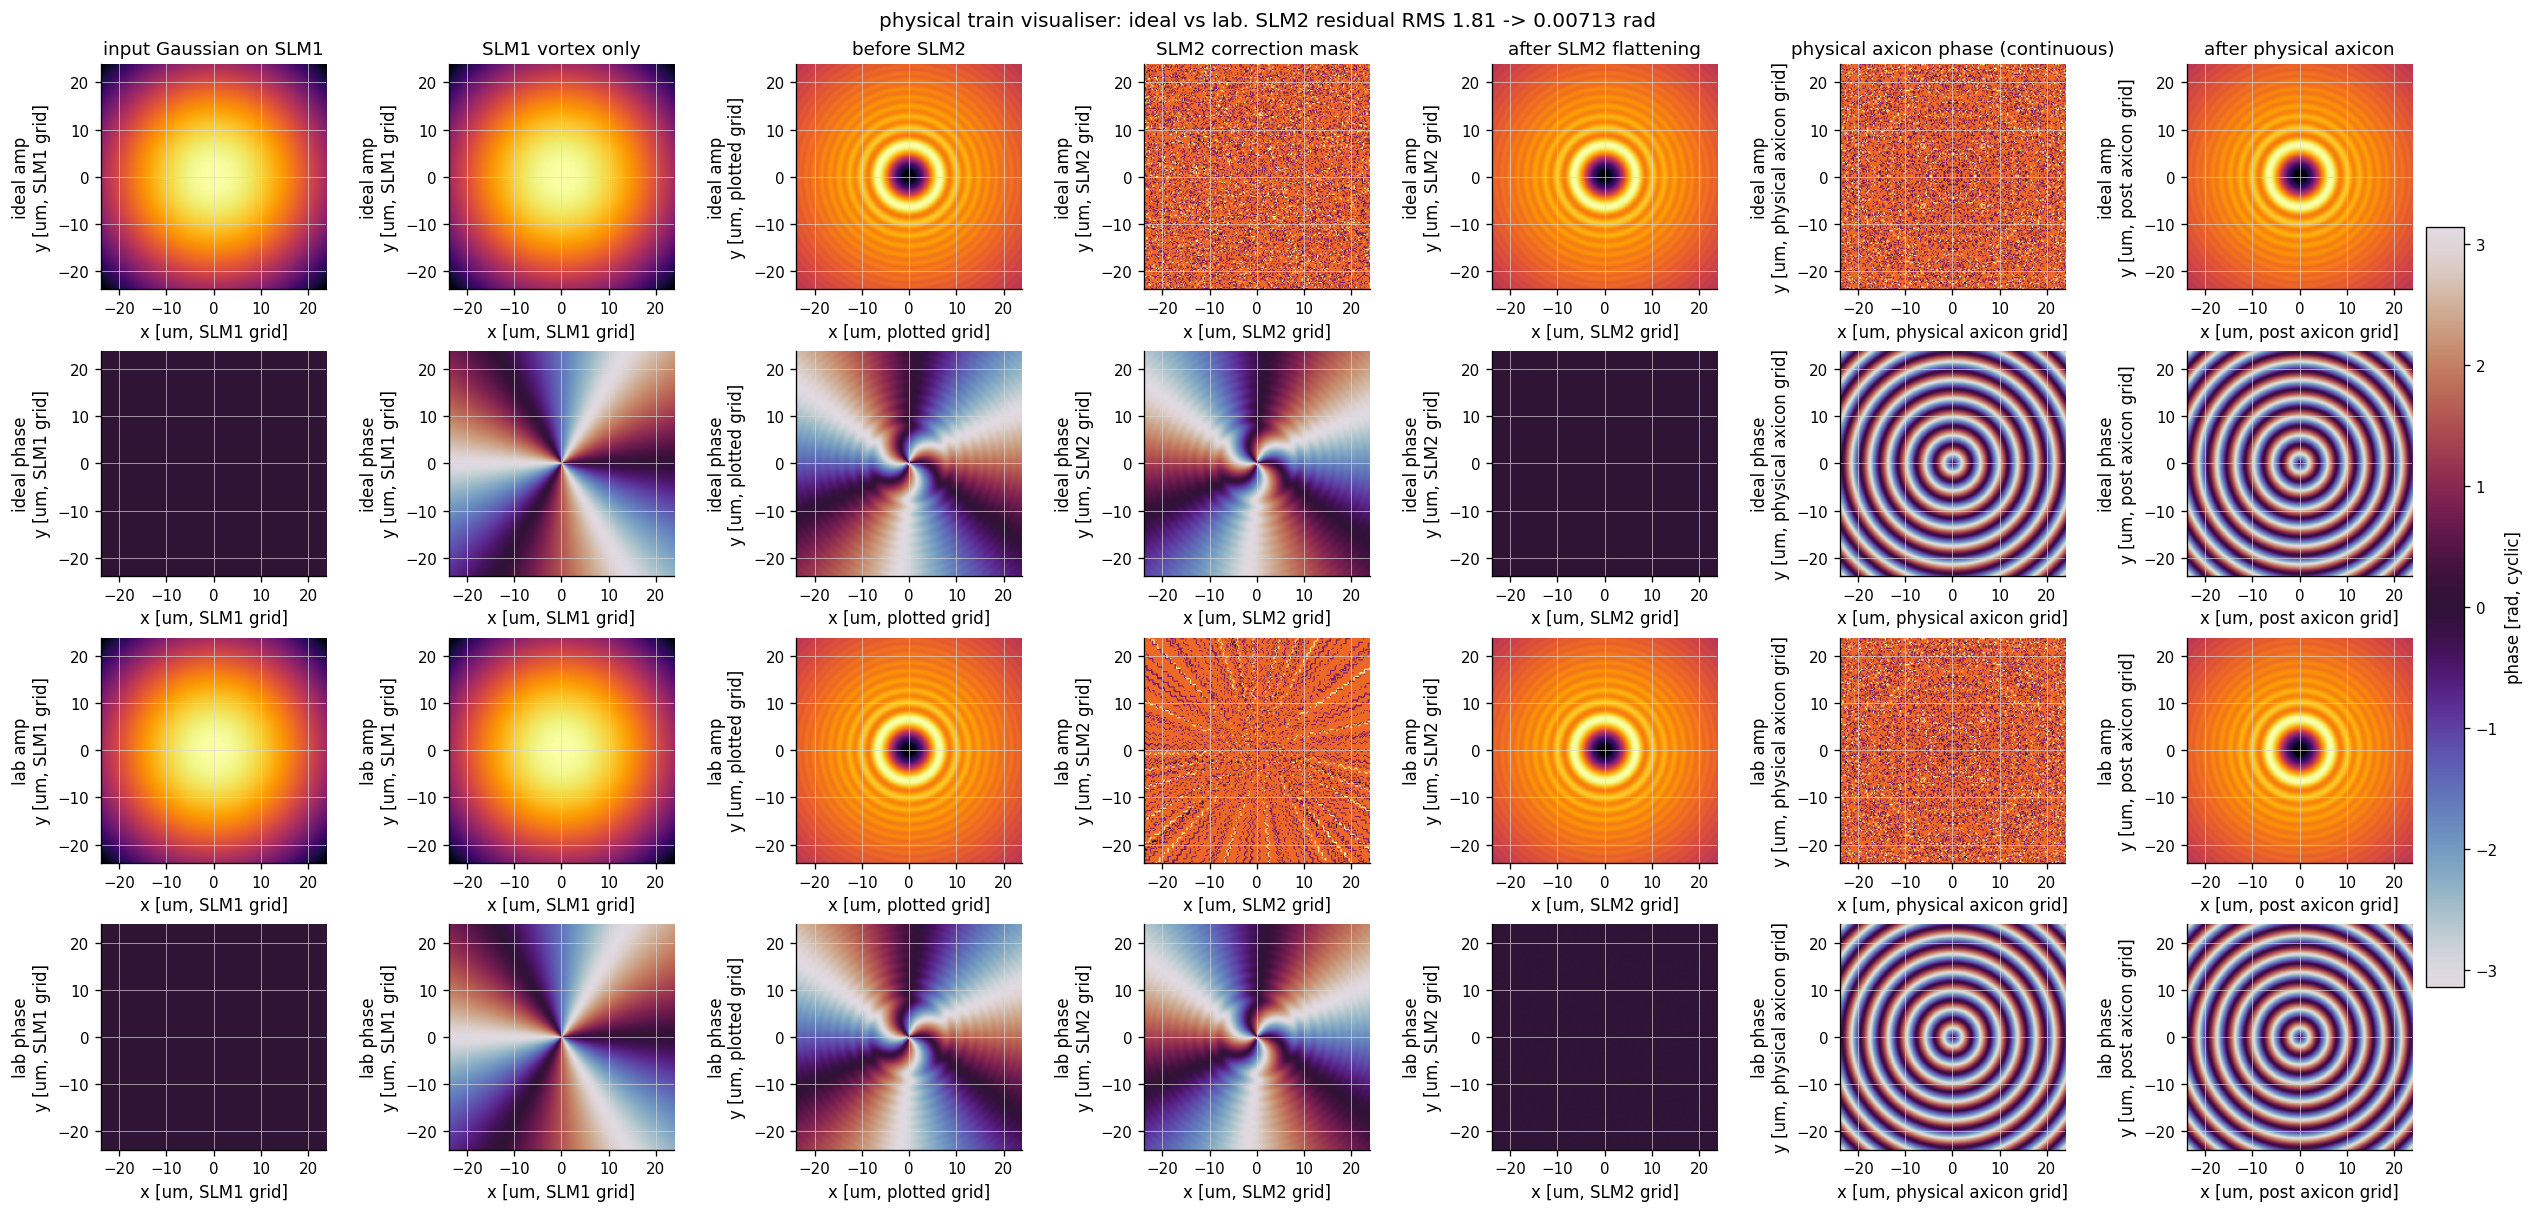

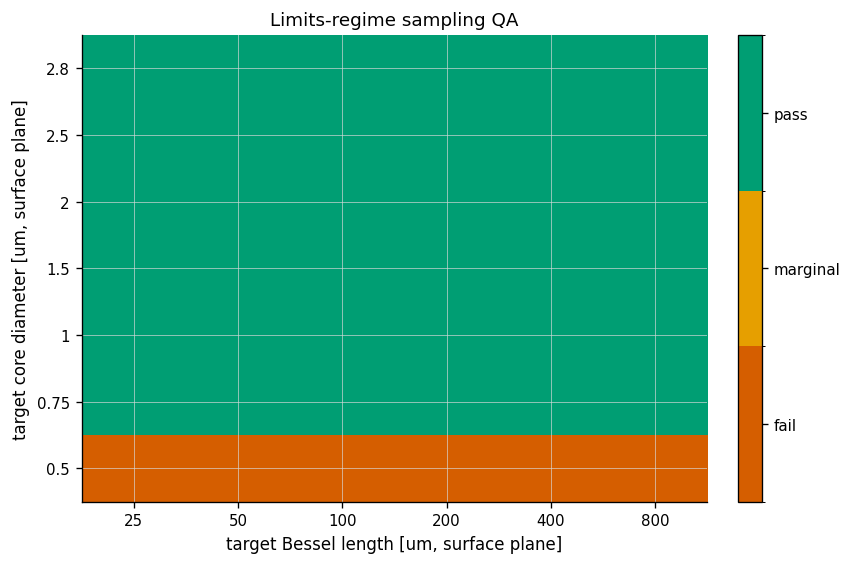

In [3]:
vbb_train_viz.plot_train_visualiser(base, method='physical', output_dir=out_fig)
vbb_train_viz.plot_sampling_qa(base, output_dir=out_fig)